# Heart - Left Ventricle LV554 bone-associated biology

1. Confirm where `LV554` sits in the SHAP-ranked Heart - Left Ventricle LVs
2. Load the precomputed significant GO-BP pathways, GWAS traits, cell-type enrichments, and KEGG hits for `LV554`
3. Recompute the top 1% genes by loading from the GTEx CLAMP Z matrix following notebook `05_top_genes_lvs_gtex.ipynb`
4. Save LV554-focused tables and figure files


💡 **Environment:** `clamp-analyses`


## Libraries


In [1]:
library(here)
library(dplyr)
library(ggplot2)
library(ggrepel)
library(stringr)


here() starts at /home/msubirana/Documents/pivlab/clamp-analyses


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Settings and helpers


In [2]:
TISSUE        <- "Heart - Left Ventricle"
LV_ID         <- "LV554"
TOP_GENE_PCT      <- 0.01
N_LABEL_GENES     <- 10
TOP_TRAITS_PLOT   <- 5
TOP_CELLTYPES_PLOT <- 5

SHAP_PATH  <- here("output/03_model_biology/01_gtex/02_LV_importance_kmeans_biology/all_shap_positive.tsv")
BP_PATH    <- here("output/99_panels/fig2/bp_data_heart_left_ventricle.csv")
TRAIT_PATH <- here("output/99_panels/fig2/trait_data_heart_left_ventricle.csv")
ORA_PATH   <- here("output/99_panels/fig2/tissue_ora_heart_left_ventricle.csv")
MODEL_PATH <- here("output/01_model_building/02_gtex/01_CLAMP/CLAMPfull.rds")
OUT_DIR    <- here("output/99_panels/fig2/lv554_heart_bone")

dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)
set.seed(42)

sanitize_stub <- function(x) {
    x <- tolower(x)
    x <- gsub("[^[:alnum:]]+", "_", x)
    x <- gsub("^_|_$", "", x)
    gsub("_+", "_", x)
}

clean_go <- function(x) {
    x %>%
        str_remove("^BP_") %>%
        str_replace_all("_", " ")
}

clean_term <- function(x) {
    x %>%
        str_replace("^KEGG_", "") %>%
        str_replace_all("_", " ")
}

theme_bubble_plot <- function(base_size = 11) {
    theme_classic(base_size = base_size) %+replace%
        theme(
            axis.line = element_line(color = "black", linewidth = 0.4),
            axis.ticks = element_line(color = "black", linewidth = 0.35),
            plot.title = element_text(face = "bold", hjust = 0.5, size = base_size + 1),
            legend.key.size = grid::unit(0.45, "cm"),
            legend.text = element_text(size = base_size - 2),
            legend.title = element_text(size = base_size - 1)
        )
}

make_bubble_plot <- function(plot_df, title_text, size_lab = NULL, point_size = 3.5) {
    plot_df <- plot_df %>%
        mutate(label = factor(label, levels = rev(label)))

    p <- ggplot(plot_df, aes(x = neg_log_fdr, y = label, color = neg_log_fdr)) +
        scale_color_gradient(low = "#d8f3dc", high = "#1b8a5a") +
        scale_x_continuous(expand = expansion(mult = c(0.02, 0.08))) +
        labs(
            title = title_text,
            x = "-log10(FDR)",
            y = NULL,
            color = "-log10(FDR)"
        ) +
        theme_bubble_plot()

    if (is.null(size_lab)) {
        p + geom_point(size = point_size, alpha = 0.9) + guides(size = "none")
    } else {
        p +
            geom_point(aes(size = size_value), alpha = 0.9) +
            labs(size = size_lab)
    }
}


## LV554 in the Heart SHAP ranking


In [3]:
shap_df <- read.delim(SHAP_PATH, sep = "\t", stringsAsFactors = FALSE)

heart_lv_tbl <- shap_df %>%
    filter(Tissue == TISSUE) %>%
    arrange(Rank)

target_lv <- heart_lv_tbl %>%
    filter(Feature == LV_ID) %>%
    select(Tissue, Feature, Mean_SHAP_Tissue, Cumulative_Percent, Rank)

top_heart_lvs <- heart_lv_tbl %>%
    slice_head(n = 6) %>%
    select(Rank, Feature, Mean_SHAP_Tissue, Cumulative_Percent)

stopifnot(nrow(target_lv) == 1)

target_lv
top_heart_lvs


Tissue,Feature,Mean_SHAP_Tissue,Cumulative_Percent,Rank
<chr>,<chr>,<dbl>,<dbl>,<int>
Heart - Left Ventricle,LV554,0.03955986,11.98061,2


Rank,Feature,Mean_SHAP_Tissue,Cumulative_Percent
<int>,<chr>,<dbl>,<dbl>
1,LV505,0.07538633,7.857362
2,LV554,0.03955986,11.980605
3,LV76,0.03777076,15.917374
4,LV137,0.03156675,19.207511
5,LV9,0.03133837,22.473845
6,LV203,0.02920713,25.518044


## Significant LV554 results


In [4]:
bp_df <- read.csv(BP_PATH, check.names = FALSE) %>%
    filter(LV == LV_ID) %>%
    arrange(FDR, desc(AUC))

trait_df <- read.csv(TRAIT_PATH, check.names = FALSE) %>%
    filter(LV == LV_ID) %>%
    arrange(fdr, desc(n_eff), phenotype)

ora_df <- read.csv(ORA_PATH, check.names = FALSE) %>%
    filter(LV == LV_ID) %>%
    arrange(p.adjust, desc(fold_enrich), desc(Count), ID)

cell_df <- ora_df %>%
    filter(collection == "C8") %>%
    mutate(neg_log_fdr = -log10(p.adjust))

kegg_df <- ora_df %>%
    filter(collection == "KEGG") %>%
    mutate(neg_log_fdr = -log10(p.adjust))

cat("LV554 rows\n")
cat("  GO-BP :", nrow(bp_df), "\n")
cat("  Traits:", nrow(trait_df), "\n")
cat("  C8    :", nrow(cell_df), "\n")
cat("  KEGG  :", nrow(kegg_df), "\n")


LV554 rows
  GO-BP : 1 
  Traits: 11 
  C8    : 49 
  KEGG  : 1 


## Significant GO-BP pathway


pathway,AUC,FDR
<chr>,<dbl>,<dbl>
Skeletal System Morphogenesis (GO:0048705),0.7004329,0.2050913


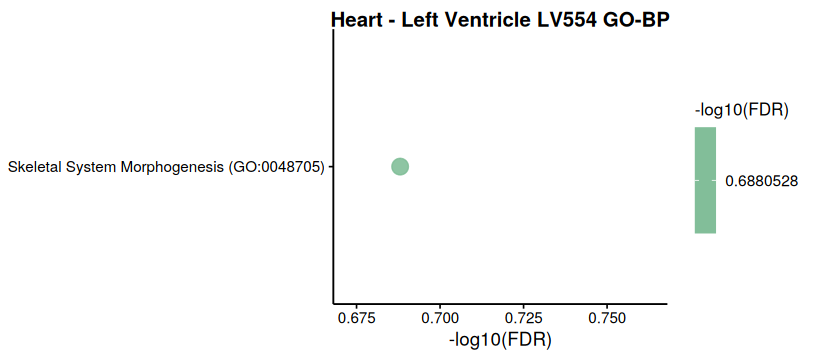

In [5]:
bp_df %>%
    transmute(
        pathway = clean_go(pathway),
        AUC,
        FDR
    )

if (nrow(bp_df) > 0) {
    bp_plot_df <- bp_df %>%
        transmute(
            label = clean_go(pathway),
            neg_log_fdr = -log10(FDR)
        )

    bp_plot <- make_bubble_plot(
        plot_df = bp_plot_df,
        title_text = paste(TISSUE, LV_ID, "GO-BP"),
        size_lab = NULL,
        point_size = 4
    )

    options(repr.plot.width = 6.8, repr.plot.height = 3.0)
    print(bp_plot)
} else {
    cat("No GO-BP rows found for", LV_ID, "\n")
}


## Significant traits


label,fdr,neg_log_fdr,size_value
<chr>,<dbl>,<dbl>,<dbl>
Heel bone mineral density (BMD),6.97191e-07,6.156648,206496
"Heel bone mineral density (BMD) T-score, automated",7.34486e-07,6.134016,206589
"Heel quantitative ultrasound index (QUI), direct entry",7.34486e-07,6.134016,206589
Heel bone mineral density (BMD) (left),9.48374e-06,5.023020,114561
"Heel bone mineral density (BMD) T-score, automated (left)",1.21015e-05,4.917161,114630


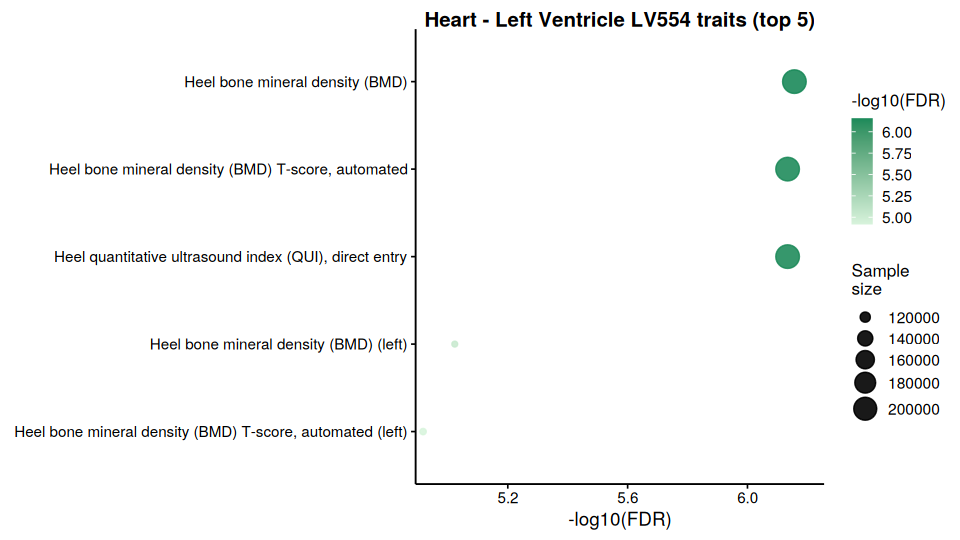

In [6]:
trait_plot_df <- trait_df %>%
    transmute(
        label = phenotype,
        fdr = fdr,
        neg_log_fdr = -log10(fdr),
        size_value = n_eff
    ) %>%
    arrange(desc(neg_log_fdr), desc(size_value), label) %>%
    slice_head(n = TOP_TRAITS_PLOT)

trait_plot_df %>%
    select(label, fdr, neg_log_fdr, size_value)

if (nrow(trait_plot_df) > 0) {
    trait_plot <- make_bubble_plot(
        plot_df = trait_plot_df,
        title_text = paste(TISSUE, LV_ID, "traits (top 5)"),
        size_lab = "Sample\nsize"
    )

    options(repr.plot.width = 8, repr.plot.height = 4.5)
    print(trait_plot)
} else {
    cat("No trait rows found for", LV_ID, "\n")
}


## Significant cell types and KEGG


label,p.adjust,neg_log_fdr,size_value,Count,geneID
<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
DESCARTES FETAL MUSCLE STROMAL CELLS,5.634902e-11,10.249114,18.320879,13,CACNA1G/CERS3-AS1/COL6A6/DKK2/FGF18/GDF6/IGFBP6/OGN/PDGFRL/PHEX/PI15/RSPO3/SHOX2
DESCARTES FETAL KIDNEY STROMAL CELLS,5.634902e-11,10.249114,12.507523,16,CBLN4/CCL19/COL14A1/COL6A6/DCLK1/DKK2/DLK1/DMRT2/FGF18/GDF6/IGF1/IGFBP6/OGN/PI15/SFRP2/WIF1
DESCARTES FETAL EYE STROMAL CELLS,7.904304e-09,8.102136,14.126144,12,ADGRG2/C1QTNF7/COL14A1/COL6A6/DKK2/FGF18/IGFBP6/OGN/PDGFRL/PTHLH/SFRP2/TWIST1
DESCARTES FETAL PLACENTA IGFBP1 DKK1 POSITIVE CELLS,8.909390e-07,6.050152,10.583289,11,ADGRG2/CACNB2/GALNT13/GAS1/IGFBP6/NDP/PCSK1/PHYHIP/PLAC9P1/PROK1/WNT5A
HAY BONE MARROW CD34 POS HSC,6.189535e-05,4.208342,8.916254,9,DLK1/HOXA3/HOXA6/HOXA7/HOXA9/HOXB3/HOXB5/HOXB6/PRKG2


ID,p.adjust,fold_enrich,Count,geneID
<chr>,<dbl>,<dbl>,<int>,<chr>
KEGG_WNT_SIGNALING_PATHWAY,0.03003402,5.075517,7,DKK2/LEF1/SFRP2/SFRP4/WIF1/WNT5A/WNT9A


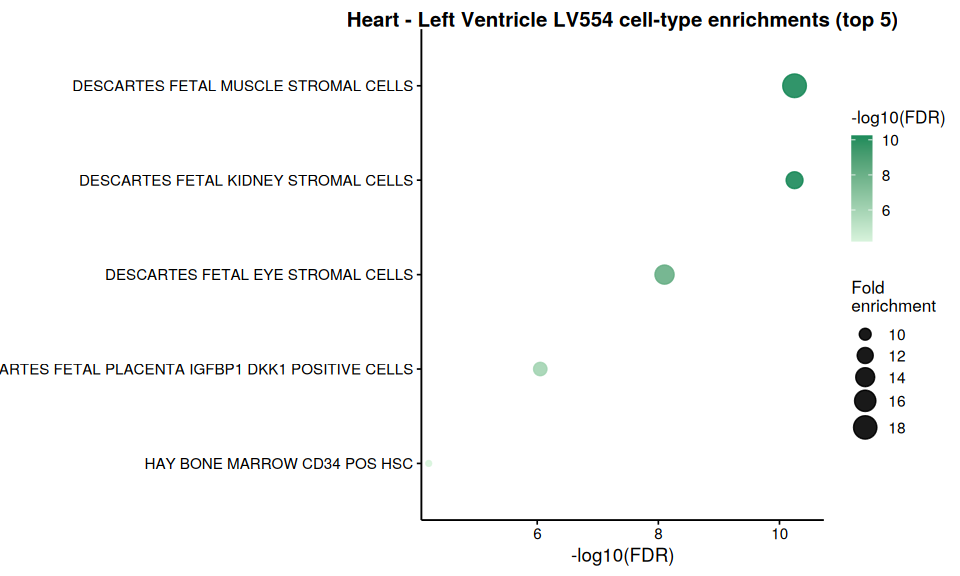

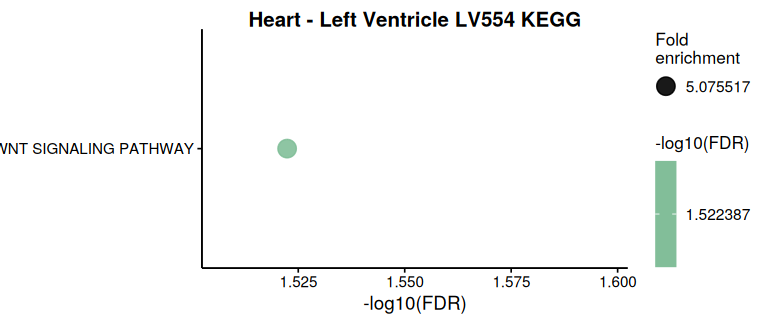

In [7]:
cell_plot_df <- cell_df %>%
    arrange(p.adjust, desc(fold_enrich), desc(Count), ID) %>%
    slice_head(n = TOP_CELLTYPES_PLOT) %>%
    transmute(
        label = str_replace_all(ID, "_", " "),
        p.adjust = p.adjust,
        neg_log_fdr = neg_log_fdr,
        size_value = fold_enrich,
        Count = Count,
        geneID = geneID
    )

cell_plot_df %>%
    select(label, p.adjust, neg_log_fdr, size_value, Count, geneID)

if (nrow(cell_plot_df) > 0) {
    cell_plot <- make_bubble_plot(
        plot_df = cell_plot_df,
        title_text = paste(TISSUE, LV_ID, "cell-type enrichments (top 5)"),
        size_lab = "Fold\nenrichment"
    )

    options(repr.plot.width = 8, repr.plot.height = 4.8)
    print(cell_plot)
} else {
    cat("No cell-type rows found for", LV_ID, "\n")
}

kegg_df %>%
    select(ID, p.adjust, fold_enrich, Count, geneID)

if (nrow(kegg_df) > 0) {
    kegg_plot_df <- kegg_df %>%
        transmute(
            label = clean_term(ID),
            neg_log_fdr = -log10(p.adjust),
            size_value = fold_enrich
        )

    kegg_plot <- make_bubble_plot(
        plot_df = kegg_plot_df,
        title_text = paste(TISSUE, LV_ID, "KEGG"),
        size_lab = "Fold\nenrichment"
    )

    options(repr.plot.width = 6.4, repr.plot.height = 2.7)
    print(kegg_plot)
} else {
    cat("No KEGG rows found for", LV_ID, "\n")
}


## Top genes following notebook 05


Z matrix: 21613 genes x 578 LVs


,Tissue,LV,panel,file_stub,rank,gene,loading,label
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<chr>
PAPPA2,Heart - Left Ventricle,LV554,Heart - Left Ventricle LV554,heart_left_ventricle_lv554,1,PAPPA2,3.008578,PAPPA2
TBX5,Heart - Left Ventricle,LV554,Heart - Left Ventricle LV554,heart_left_ventricle_lv554,2,TBX5,1.988432,TBX5
ADAMTS3,Heart - Left Ventricle,LV554,Heart - Left Ventricle LV554,heart_left_ventricle_lv554,3,ADAMTS3,1.859989,ADAMTS3
CD8BP,Heart - Left Ventricle,LV554,Heart - Left Ventricle LV554,heart_left_ventricle_lv554,4,CD8BP,1.813316,CD8BP
SFRP4,Heart - Left Ventricle,LV554,Heart - Left Ventricle LV554,heart_left_ventricle_lv554,5,SFRP4,1.708217,SFRP4
ESR1,Heart - Left Ventricle,LV554,Heart - Left Ventricle LV554,heart_left_ventricle_lv554,6,ESR1,1.612678,ESR1
KCNJ2,Heart - Left Ventricle,LV554,Heart - Left Ventricle LV554,heart_left_ventricle_lv554,7,KCNJ2,1.534670,KCNJ2
KCNJ2-AS1,Heart - Left Ventricle,LV554,Heart - Left Ventricle LV554,heart_left_ventricle_lv554,8,KCNJ2-AS1,1.486639,KCNJ2-AS1
LINC01239,Heart - Left Ventricle,LV554,Heart - Left Ventricle LV554,heart_left_ventricle_lv554,9,LINC01239,1.300509,LINC01239


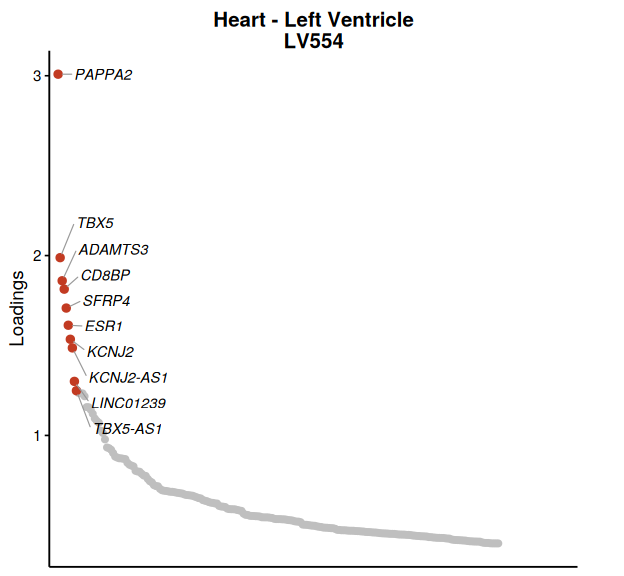

In [8]:
clamp_model <- readRDS(MODEL_PATH)
Z <- as.matrix(clamp_model$Z)

stopifnot(LV_ID %in% colnames(Z))
cat("Z matrix:", nrow(Z), "genes x", ncol(Z), "LVs\n")

get_top_loading_genes <- function(tissue, lv, file_stub, z_mat, top_gene_pct = 0.01, n_label_genes = 10) {
    loadings <- z_mat[, lv]
    n_top    <- max(1L, ceiling(length(loadings) * top_gene_pct))
    ord      <- order(loadings, decreasing = TRUE)

    data.frame(
        Tissue    = tissue,
        LV        = lv,
        panel     = paste0(tissue, "\n", lv),
        file_stub = file_stub,
        rank      = seq_len(n_top),
        gene      = rownames(z_mat)[ord][seq_len(n_top)],
        loading   = loadings[ord][seq_len(n_top)],
        label     = ifelse(
            seq_len(n_top) <= n_label_genes,
            rownames(z_mat)[ord][seq_len(n_top)],
            NA_character_
        ),
        stringsAsFactors = FALSE
    )
}

theme_loading_plot <- function(base_size = 11) {
    theme_classic(base_size = base_size) %+replace%
        theme(
            axis.line = element_line(color = "black", linewidth = 0.4),
            axis.ticks = element_line(color = "black", linewidth = 0.35),
            axis.text.x = element_blank(),
            axis.ticks.x = element_blank(),
            axis.title.x = element_blank(),
            plot.title = element_text(face = "bold", hjust = 0.5, size = base_size + 1),
            plot.margin = margin(5.5, 28, 5.5, 5.5)
        )
}

make_loading_plot <- function(plot_df, label_df, title_text) {
    ggplot(plot_df, aes(x = rank, y = loading)) +
        geom_point(size = 1.2, color = "grey75") +
        geom_point(data = label_df, color = "#C23B22", size = 1.6) +
        geom_text_repel(
            data = label_df,
            aes(label = label),
            size = 3,
            fontface = "italic",
            direction = "y",
            hjust = 0,
            seed = 42,
            max.overlaps = Inf,
            min.segment.length = 0,
            box.padding = 0.3,
            point.padding = 0.2,
            nudge_x = 8,
            segment.color = "grey60",
            segment.size = 0.25
        ) +
        coord_cartesian(clip = "off") +
        scale_x_continuous(expand = expansion(mult = c(0.02, 0.18))) +
        labs(title = title_text, y = "Loadings") +
        theme_loading_plot()
}

file_stub <- paste(sanitize_stub(TISSUE), sanitize_stub(LV_ID), sep = "_")

top_gene_loadings <- get_top_loading_genes(
    tissue = TISSUE,
    lv = LV_ID,
    file_stub = file_stub,
    z_mat = Z,
    top_gene_pct = TOP_GENE_PCT,
    n_label_genes = N_LABEL_GENES
)

top_label_genes <- top_gene_loadings %>% filter(!is.na(label))
top_gene_plot <- make_loading_plot(
    plot_df = top_gene_loadings,
    label_df = top_label_genes,
    title_text = paste(TISSUE, LV_ID, sep = "\n")
)

top_gene_loadings %>%
    slice_head(n = 15)

options(repr.plot.width = 5.2, repr.plot.height = 4.8)
print(top_gene_plot)


## Save LV554 outputs
